# MAG — Grafi con attributi di nodo

Notebook basato sul modello **MAG (Multiplicative Attribute Graph)** di Kim & Leskovec (UAI 2011).

Pipeline:
1. **Generazione** di grafi sintetici con un attributo binario per nodo, campionato da `Bernoulli(μ)`.
2. La probabilità di ogni arco `(i,j)` è `Θ[F_i, F_j]` — la matrice di affinità `Θ` determina la struttura.
3. **Embedding** EDRep di ogni grafo con i nodi partizionati per attributo.
4. **Distanza W2** tra coppie di grafi usando `block_dists` + `graph_distance` da `functions.py`.
5. **Visualizzazione** della matrice di distanze e dei contributi per blocco.

Tre regimi strutturali (come Figura 5 del paper):
- **Homophily**: nodi con lo stesso attributo si connettono più spesso
- **Heterophily**: nodi con attributo diverso si connettono più spesso
- **Core-Periphery**: attributo 0 = core denso, attributo 1 = periferia sparsa

In [25]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
import sys
import os

from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics import confusion_matrix

# Project root is two levels up from notebooks/experiments/
sys.path.insert(0, os.path.abspath('../..'))

from functions import (
    node_embedding,
    block_dists,
    graph_distance,
    w2_distance_classes,
    plot_wasserstein_heatmap,
)

## 1. Generatore MAG (L = 1 attributo binario)

In [26]:
def generate_mag_graph(n, mu, Theta, seed=None):
    """
    Genera un grafo MAG con un singolo attributo binario per nodo.

    Ogni nodo i riceve un attributo F_i ~ Bernoulli(mu).
    La probabilità dell'arco (i,j) è Theta[F_i, F_j].

    Parameters
    ----------
    n     : numero di nodi
    mu    : parametro Bernoulli per l'attributo binario
    Theta : matrice di affinità 2x2  (Theta[a,b] = prob arco tra nodi con attr a e b)
    seed  : seed per la riproducibilità

    Returns
    -------
    G : networkx.Graph con attributo di nodo 'attribute' in {0, 1}
    F : np.ndarray di forma (n,) — vettore degli attributi
    """
    rng = np.random.default_rng(seed)
    F = rng.binomial(1, mu, n)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        G.nodes[i]['attribute'] = int(F[i])

    # Campionamento vettorizzato degli archi tramite indici triangolari superiori
    i_idx, j_idx = np.triu_indices(n, k=1)
    p_ij = Theta[F[i_idx], F[j_idx]]
    mask = rng.random(len(i_idx)) < p_ij
    G.add_edges_from(zip(i_idx[mask].tolist(), j_idx[mask].tolist()))

    return G, F

## 2. Definizione dei regimi strutturali

In [27]:
n = 300       # nodi per grafo
mu = 0.5      # classi bilanciate
n_graphs = 5  # grafi per regime

# Matrici di affinità scalate per grafi sparsi (grado medio ≈ 15)
# Corrispondono ai tre casi di Figura 5 in Kim & Leskovec (2011)
settings = {
    'Homophily': np.array([[0.08, 0.01],
                            [0.01, 0.08]]),
    'Heterophily': np.array([[0.01, 0.08],
                              [0.08, 0.01]]),
    'Core-Periphery': np.array([[0.12, 0.05],
                                 [0.05, 0.01]]),
}

print("Regimi strutturali:")
for name, Theta in settings.items():
    avg_p = mu**2 * Theta[0,0] + 2*mu*(1-mu) * Theta[0,1] + (1-mu)**2 * Theta[1,1]
    expected_degree = avg_p * (n - 1)
    print(f"  {name}: grado medio atteso ≈ {expected_degree:.1f}")

Regimi strutturali:
  Homophily: grado medio atteso ≈ 13.5
  Heterophily: grado medio atteso ≈ 13.5
  Core-Periphery: grado medio atteso ≈ 17.2


## 3. Generazione dei grafi

In [28]:
graphs = {}  # nome -> list of (G, F)
for name, Theta in settings.items():
    graphs[name] = [generate_mag_graph(n, mu, Theta, seed=s) for s in range(n_graphs)]
    G0, F0 = graphs[name][0]
    print(f"{name}:")
    print(f"  nodi={G0.number_of_nodes()}, archi={G0.number_of_edges()}, "
          f"attr-0: {int((F0==0).sum())}, attr-1: {int((F0==1).sum())}")

Homophily:
  nodi=300, archi=2068, attr-0: 135, attr-1: 165
Heterophily:
  nodi=300, archi=2024, attr-0: 135, attr-1: 165
Core-Periphery:
  nodi=300, archi=2342, attr-0: 135, attr-1: 165


## 4. Visualizzazione — un grafo di esempio per regime

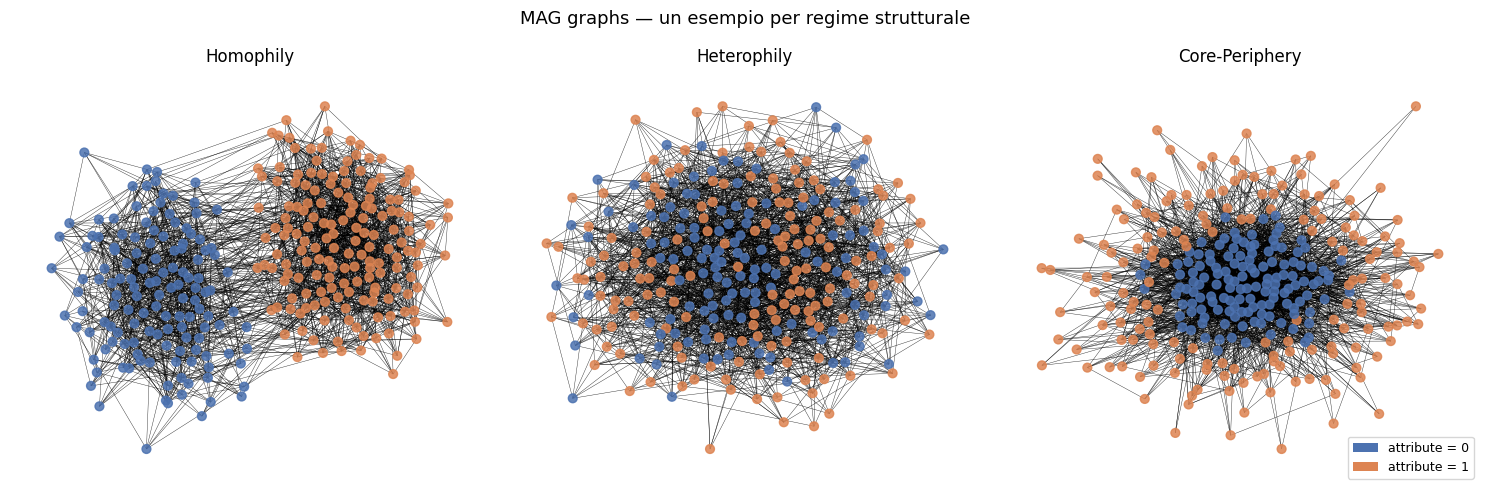

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('MAG graphs — un esempio per regime strutturale', fontsize=13)

color_map = {0: '#4C72B0', 1: '#DD8452'}  # blu=attr0, arancio=attr1

for ax, (name, gs) in zip(axes, graphs.items()):
    G, F = gs[0]
    pos = nx.spring_layout(G, seed=42, k=0.4)
    node_colors = [color_map[int(f)] for f in F]
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=40,
        width=0.3,
        alpha=0.85,
        with_labels=False,
    )
    ax.set_title(name, fontsize=12)
    ax.axis('off')

legend_elements = [
    mpatches.Patch(facecolor='#4C72B0', label='attribute = 0'),
    mpatches.Patch(facecolor='#DD8452', label='attribute = 1'),
]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Embedding EDRep e block distributions

Per ogni grafo:
1. Si partizionano i nodi per attributo: `partition = [nodi con attr=0, nodi con attr=1]`
2. `node_embedding(G, partition, dim)` calcola l'embedding EDRep e restituisce la lista di submatrix per classe
3. `block_dists(X_list)` estrae la distribuzione dei prodotti scalari per ogni blocco `(i,j)`

In [30]:
import ot

dim = 32
bd_all = {}        # (setting_name, graph_idx) -> dizionario block_dists
X_lists_all = {}   # (setting_name, graph_idx) -> X_list  (salvato per il confronto sezione 11)

for name, gs in graphs.items():
    for idx, (G, F) in enumerate(gs):
        # Partizione per attributo binario
        partition = [
            np.where(F == 0)[0].tolist(),
            np.where(F == 1)[0].tolist(),
        ]
        # Embedding con nodi partizionati
        X_list = node_embedding(G, partition, dim_embedding=dim, seed=42)
        # Distribuzione per blocco (intra-classe e inter-classe)
        bd_all[(name, idx)] = block_dists(X_list)
        X_lists_all[(name, idx)] = X_list   # tenuto per confronto partizionato vs no
    print(f"{name}: embeddings calcolati")

print(f"\nTotale grafi: {len(bd_all)}")
sample_bd = list(bd_all.values())[0]
print(f"Blocchi per grafo: {list(sample_bd.keys())}")
print("  (0,0) = intra-classe attr=0, (1,1) = intra-classe attr=1, (0,1) = inter-classe")

Homophily: embeddings calcolati
Heterophily: embeddings calcolati
Core-Periphery: embeddings calcolati

Totale grafi: 15
Blocchi per grafo: [(0, 0), (0, 1), (1, 1)]
  (0,0) = intra-classe attr=0, (1,1) = intra-classe attr=1, (0,1) = inter-classe


## 6. Matrice delle distanze pairwise

`graph_distance(bd_a, bd_b)` calcola la norma L2 delle distanze Wasserstein-1D per ciascun blocco.

In [31]:
keys = list(bd_all.keys())
N = len(keys)
D = np.zeros((N, N))

for i, j in itertools.combinations(range(N), 2):
    d = graph_distance(bd_all[keys[i]], bd_all[keys[j]])
    D[i, j] = D[j, i] = d

labels = [f"{name[:4]}-{idx}" for name, idx in keys]

# Statistiche riassuntive
names = list(settings.keys())
n_g = n_graphs
print("Distanze medie intra-regime:")
for k, nm in enumerate(names):
    block = D[k*n_g:(k+1)*n_g, k*n_g:(k+1)*n_g]
    intra = block[np.triu_indices(n_g, k=1)]
    print(f"  {nm}: {intra.mean():.4f}")

print("\nDistanze medie cross-regime:")
regime_pairs = list(itertools.combinations(range(len(names)), 2))
for ki, kj in regime_pairs:
    cross = D[ki*n_g:(ki+1)*n_g, kj*n_g:(kj+1)*n_g]
    print(f"  {names[ki]} vs {names[kj]}: {cross.mean():.4f}")

Distanze medie intra-regime:
  Homophily: 0.1086
  Heterophily: 0.0114
  Core-Periphery: 0.0107

Distanze medie cross-regime:
  Homophily vs Heterophily: 0.7396
  Homophily vs Core-Periphery: 0.7334
  Heterophily vs Core-Periphery: 0.0229


## 7. Heatmap delle distanze

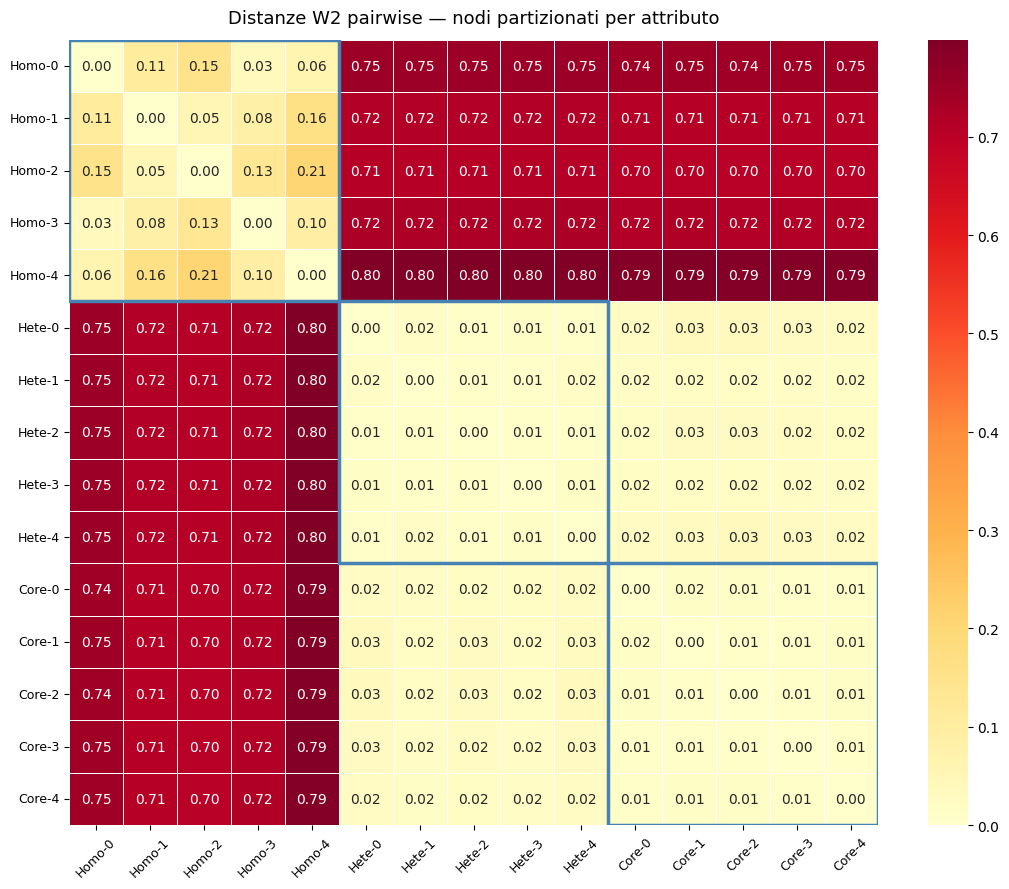

In [32]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    D,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
)

# Rettangoli blu attorno ai blocchi intra-regime
for k in range(len(names)):
    ax.add_patch(plt.Rectangle(
        (k * n_g, k * n_g), n_g, n_g,
        fill=False, edgecolor='steelblue', lw=2.5,
    ))

ax.set_title('Distanze W2 pairwise — nodi partizionati per attributo', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

## 8. Verifica: `block_dists + graph_distance` ≡ `w2_distance_classes`

Le due chiamate calcolano la stessa quantità: `block_dists` pre-ordina i valori (ottimizzazione),
`w2_distance_classes` li usa direttamente. `ot.wasserstein_1d` è invariante all'ordinamento
quindi i risultati devono coincidere numericamente.

In [33]:
G1, F1 = graphs['Homophily'][0]
G2, F2 = graphs['Heterophily'][0]

p1 = [np.where(F1 == 0)[0].tolist(), np.where(F1 == 1)[0].tolist()]
p2 = [np.where(F2 == 0)[0].tolist(), np.where(F2 == 1)[0].tolist()]

X1 = node_embedding(G1, p1, dim_embedding=dim, seed=42)
X2 = node_embedding(G2, p2, dim_embedding=dim, seed=42)

d_bd = graph_distance(block_dists(X1), block_dists(X2))
d_w2, D_vec_verify, _ = w2_distance_classes(X1, X2)

print(f"graph_distance(block_dists(..), block_dists(..)) : {d_bd:.6f}")
print(f"w2_distance_classes(..)                          : {d_w2:.6f}")
print(f"Differenza relativa                              : {abs(d_bd - d_w2) / d_w2 * 100:.4f}%")

graph_distance(block_dists(..), block_dists(..)) : 0.751618
w2_distance_classes(..)                          : 0.751618
Differenza relativa                              : 0.0000%


## 9. Contributo per blocco — Heatmap (Homophily vs Core-Periphery)

Decompone la distanza totale nei tre blocchi: `(0,0)` intra-classe attr=0,
`(1,1)` intra-classe attr=1, `(0,1)` inter-classe.

Distanze per blocco (Homophily vs Core-Periphery):
  Blocco (0,0): 0.4829  (64.9% del totale)
  Blocco (0,1): 0.4250  (57.1% del totale)
  Blocco (1,1): 0.3731  (50.2% del totale)
Distanza totale (norma L2): 0.7437


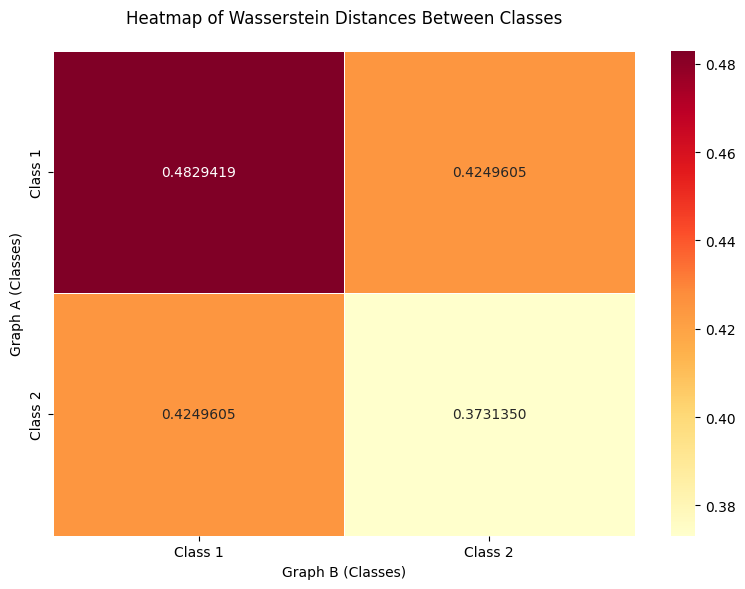

In [34]:
G_h, F_h = graphs['Homophily'][0]
G_c, F_c = graphs['Core-Periphery'][0]

p_h = [np.where(F_h == 0)[0].tolist(), np.where(F_h == 1)[0].tolist()]
p_c = [np.where(F_c == 0)[0].tolist(), np.where(F_c == 1)[0].tolist()]

X_h = node_embedding(G_h, p_h, dim_embedding=dim, seed=42)
X_c = node_embedding(G_c, p_c, dim_embedding=dim, seed=42)

d_total, D_vec, _ = w2_distance_classes(X_h, X_c)

block_names = ['(0,0)', '(0,1)', '(1,1)']
print("Distanze per blocco (Homophily vs Core-Periphery):")
for bl, dv in zip(block_names, D_vec):
    print(f"  Blocco {bl}: {dv:.4f}  ({dv/d_total*100:.1f}% del totale)")
print(f"Distanza totale (norma L2): {d_total:.4f}")

plot_wasserstein_heatmap(D_vec, m=2)

## 10. Clustering dei grafi e NMI

`ClusterNMF` (da `comparison_models.ipynb`) fattorizza la matrice delle distanze `D` con **NMF**
e raggruppa con **K-Means**, ripetendo 20 volte per trovare la soluzione ottimale.

Il risultato viene confrontato con le etichette vere dei regimi tramite
`normalized_mutual_info_score` (NMI), come in `comparison_models.ipynb`.

### 10a. NMI globale e confusion matrix

In [35]:
def NMF_kmeans(M, k):
    """Fattorizza M con NMF e raggruppa le componenti con K-Means.
    Identica a NMF_kmeans in comparison_models.ipynb."""
    n, _ = M.shape
    Mt = M + np.eye(n) * np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)
    Y = NMF(n_components=k, max_iter=2000).fit(Mt).components_
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))


def ClusterNMF(M, k):
    """Ripete NMF_kmeans 20 volte e restituisce la soluzione con score minore.
    Identica a ClusterNMF in comparison_models.ipynb."""
    est_l, score = NMF_kmeans(M, k)
    for _ in range(20):
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_
            est_l = est_l_
    return est_l

Etichette vere:     [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]
Etichette predette: [1 1 1 1 1 0 2 0 0 2 2 0 0 2 0]

NMI globale (3 regimi): 0.5829
(NMI = 1.0 → clustering perfetto  |  NMI = 0.0 → casuale)


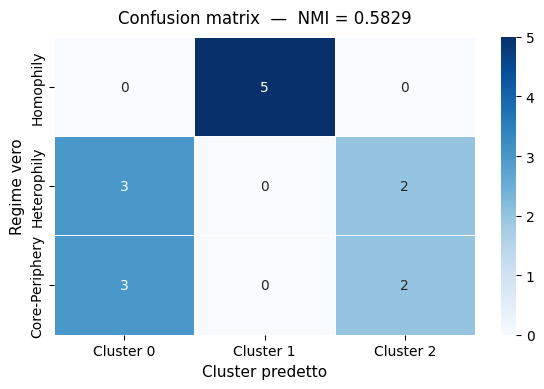

In [36]:
regime_names = list(settings.keys())
k = len(regime_names)

# Etichette vere: n_graphs grafi per regime nell'ordine del dizionario settings
l_true = np.concatenate([[i] * n_graphs for i in range(k)])

# Clustering con ClusterNMF sulla matrice delle distanze (identico a comparison_models.ipynb)
l_pred = ClusterNMF(D, k)

nmi_global = NMI(l_pred, l_true)
print(f"Etichette vere:     {l_true}")
print(f"Etichette predette: {l_pred}")
print(f"\nNMI globale (3 regimi): {nmi_global:.4f}")
print("(NMI = 1.0 → clustering perfetto  |  NMI = 0.0 → casuale)")

# Confusion matrix
cm = confusion_matrix(l_true, l_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Cluster {i}' for i in range(k)],
    yticklabels=regime_names,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f'Confusion matrix  —  NMI = {nmi_global:.4f}', fontsize=12, pad=10)
ax.set_xlabel('Cluster predetto', fontsize=11)
ax.set_ylabel('Regime vero', fontsize=11)
plt.tight_layout()
plt.show()

### 10b. NMI pairwise tra regimi

Per ogni coppia di regimi, `ClusterNMF` deve separare due classi di `n_graphs` grafi ciascuna.
Si usa il blocco 10×10 della matrice `D` corrispondente ai due regimi.
Un NMI alto indica che la distanza W2 partizionata riesce a distinguere i due regimi strutturali.

NMI pairwise (separabilità tra coppie di regimi):
  Homophily            vs Heterophily         : NMI = 1.0000
  Homophily            vs Core-Periphery      : NMI = 1.0000
  Heterophily          vs Core-Periphery      : NMI = 1.0000


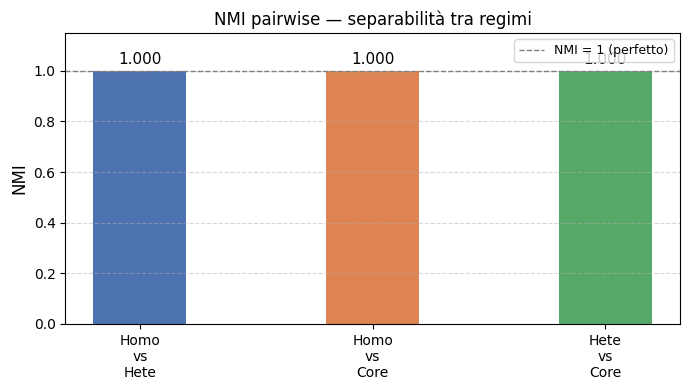

In [37]:
regime_pairs = list(itertools.combinations(range(k), 2))
nmi_pairs = {}

print("NMI pairwise (separabilità tra coppie di regimi):")
for ki, kj in regime_pairs:
    idx = np.concatenate([
        np.arange(ki * n_graphs, (ki + 1) * n_graphs),
        np.arange(kj * n_graphs, (kj + 1) * n_graphs),
    ])
    l_sub = np.concatenate([
        np.zeros(n_graphs, dtype=int),
        np.ones(n_graphs, dtype=int),
    ])
    l_sub_pred = ClusterNMF(D[np.ix_(idx, idx)], k=2)
    nmi_pairs[(ki, kj)] = NMI(l_sub_pred, l_sub)
    print(f"  {regime_names[ki]:20s} vs {regime_names[kj]:20s}: NMI = {nmi_pairs[(ki,kj)]:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
pair_labels = [
    f"{regime_names[ki][:4]}\nvs\n{regime_names[kj][:4]}"
    for ki, kj in regime_pairs
]
nmi_values = [nmi_pairs[p] for p in regime_pairs]
bars = ax.bar(pair_labels, nmi_values,
              color=['#4C72B0', '#DD8452', '#55A868'], width=0.4)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, ls='--', color='gray', lw=1, label='NMI = 1 (perfetto)')
ax.set_ylabel('NMI', fontsize=12)
ax.set_title('NMI pairwise — separabilità tra regimi', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10c. Matrice delle distanze riordinata per cluster

Riordinando righe/colonne di `D` secondo le etichette predette, i blocchi a bassa distanza
(stessa classe) appaiono sulla diagonale — segnale visivo della qualità del clustering.

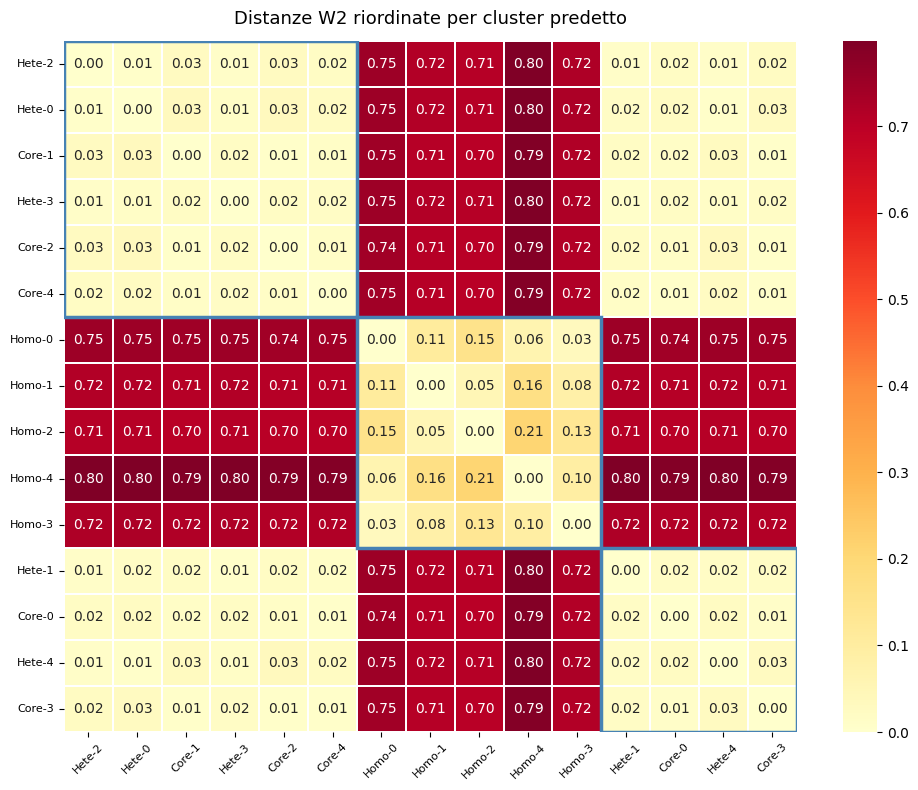

In [38]:
sort_idx = np.argsort(l_pred)
D_sorted = D[np.ix_(sort_idx, sort_idx)]
labels_sorted = [labels[i] for i in sort_idx]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    D_sorted,
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
)

# Rettangoli sui blocchi del cluster predetto
cluster_sizes = np.bincount(np.sort(l_pred))
pos = 0
for sz in cluster_sizes:
    ax.add_patch(plt.Rectangle(
        (pos, pos), sz, sz,
        fill=False, edgecolor='steelblue', lw=2.5,
    ))
    pos += sz

ax.set_title('Distanze W2 riordinate per cluster predetto', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 11. Partitioned vs Unpartitioned: la partizione migliora la discriminazione?

**Ipotesi**: la distanza W2 calcolata con i nodi partizionati per attributo
(`block_dists` + `graph_distance`) separa meglio i regimi strutturali rispetto alla
distanza W2 senza nessuna partizione (tutti i nodi in un unico blocco).

**Metrica di confronto**: NMI del clustering `ClusterNMF` sulle rispettive matrici di distanza.

**Tre test**:
- **11a** — heatmap affiancata delle due matrici di distanza
- **11b** — NMI globale + NMI pairwise: bar chart comparativo
- **11c** — violin plot: distribuzione delle distanze within-regime vs cross-regime per i due metodi

D_nopart calcolata.


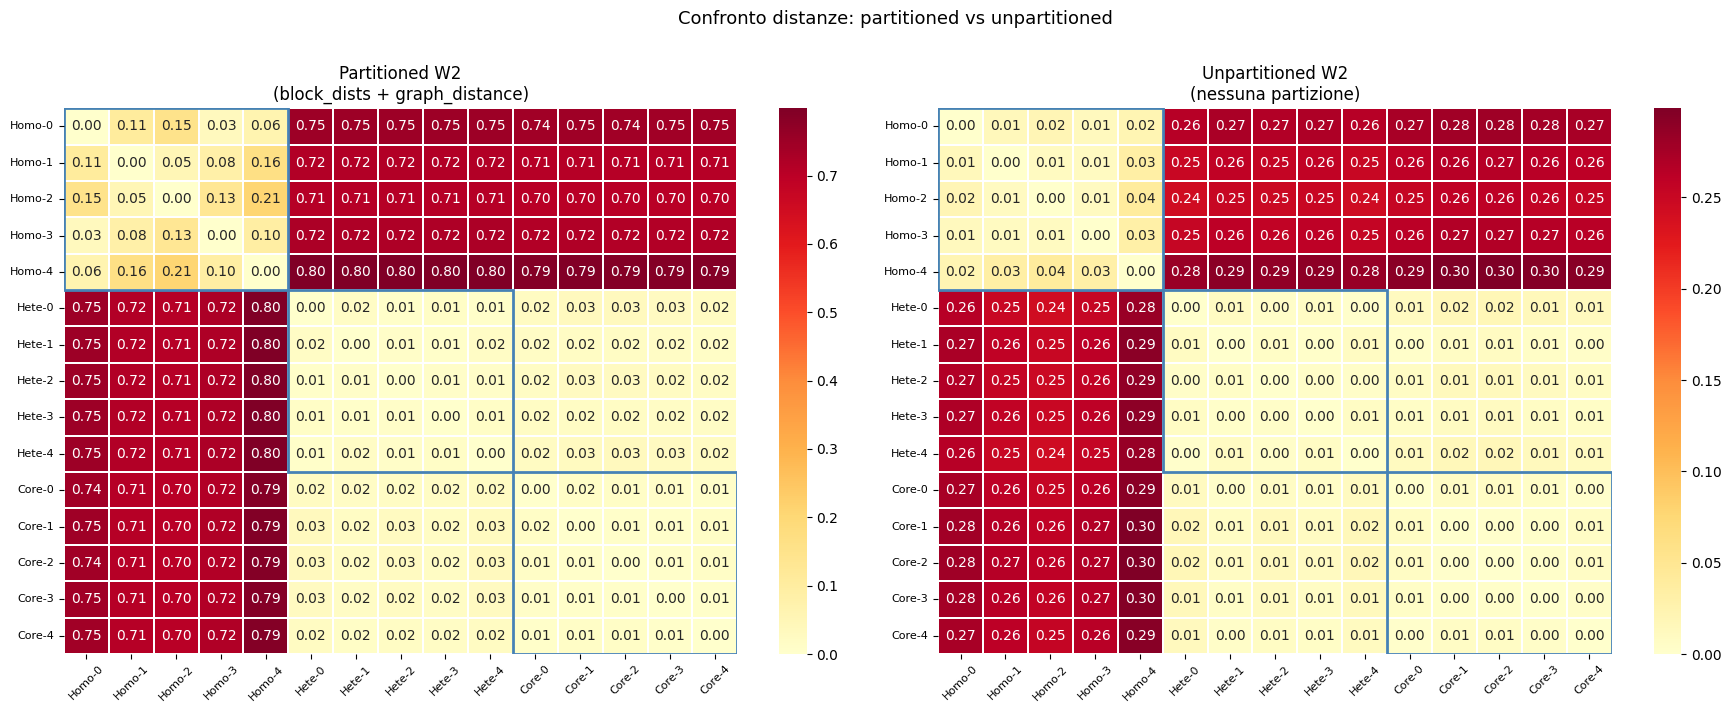

In [39]:
def w2_distance_nopart(X_list_a, X_list_b):
    """
    Distanza W2 tra due grafi SENZA partizione degli attributi.

    Concatena gli embedding delle due classi, calcola la distribuzione
    di tutti i prodotti scalari (triangolo superiore di X @ X.T) e
    calcola la W2-1D tra le due distribuzioni.
    """
    X_a = np.concatenate(X_list_a, axis=0)
    X_b = np.concatenate(X_list_b, axis=0)
    S_a = X_a @ X_a.T
    S_b = X_b @ X_b.T
    vals_a = S_a[np.triu_indices_from(S_a, k=1)]
    vals_b = S_b[np.triu_indices_from(S_b, k=1)]
    return ot.wasserstein_1d(vals_a, vals_b, p=2) ** 0.5


# Matrice delle distanze senza partizione
D_nopart = np.zeros((N, N))
for i, j in itertools.combinations(range(N), 2):
    d = w2_distance_nopart(X_lists_all[keys[i]], X_lists_all[keys[j]])
    D_nopart[i, j] = D_nopart[j, i] = d

print("D_nopart calcolata.")

# Heatmap affiancata: partitioned vs unpartitioned
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (mat, title) in zip(axes, [
    (D,        'Partitioned W2\n(block_dists + graph_distance)'),
    (D_nopart, 'Unpartitioned W2\n(nessuna partizione)'),
]):
    sns.heatmap(mat, xticklabels=labels, yticklabels=labels,
                cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.3, linecolor='white', ax=ax)
    for kk in range(len(names)):
        ax.add_patch(plt.Rectangle(
            (kk * n_g, kk * n_g), n_g, n_g,
            fill=False, edgecolor='steelblue', lw=2.0,
        ))
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Confronto distanze: partitioned vs unpartitioned', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


NMI  partitioned   (block_dists + graph_distance) : 0.5829
NMI  unpartitioned (W2 senza partizione)          : 0.6497

Miglioramento:  Δ NMI = -0.0667

NMI pairwise:
  Homophily            vs Heterophily           partitioned=1.000   unpartitioned=1.000
  Homophily            vs Core-Periphery        partitioned=1.000   unpartitioned=1.000
  Heterophily          vs Core-Periphery        partitioned=1.000   unpartitioned=0.421


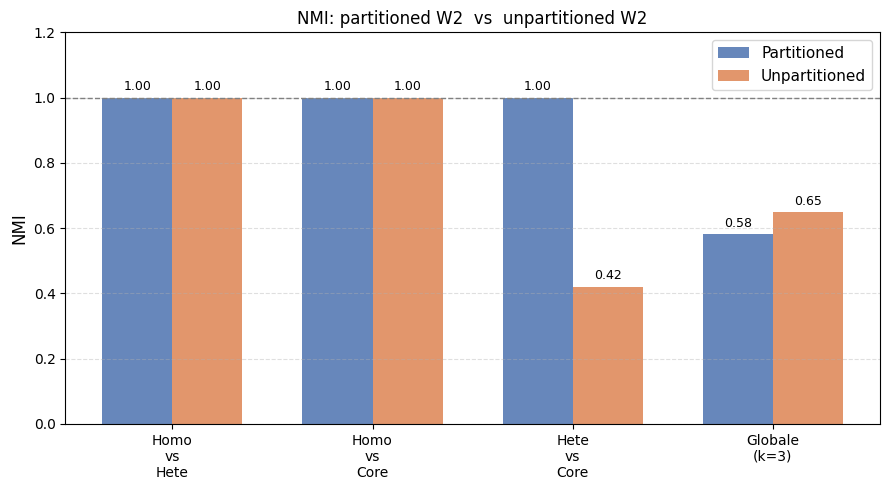

In [40]:
# NMI per entrambi i metodi ─────────────────────────────────────────────────
nmi_part_global   = NMI(ClusterNMF(D,        k), l_true)
nmi_nopart_global = NMI(ClusterNMF(D_nopart, k), l_true)

print(f"NMI  partitioned   (block_dists + graph_distance) : {nmi_part_global:.4f}")
print(f"NMI  unpartitioned (W2 senza partizione)          : {nmi_nopart_global:.4f}")
print(f"\nMiglioramento:  Δ NMI = {nmi_part_global - nmi_nopart_global:+.4f}")

# NMI pairwise per entrambi i metodi ─────────────────────────────────────────
print("\nNMI pairwise:")
regime_pairs_all = list(itertools.combinations(range(k), 2))
nmi_p_pairs, nmi_np_pairs = [], []

for ki, kj in regime_pairs_all:
    idx = np.concatenate([
        np.arange(ki * n_graphs, (ki + 1) * n_graphs),
        np.arange(kj * n_graphs, (kj + 1) * n_graphs),
    ])
    l_sub = np.concatenate([np.zeros(n_graphs, dtype=int), np.ones(n_graphs, dtype=int)])
    nmi_p  = NMI(ClusterNMF(D[np.ix_(idx, idx)],        k=2), l_sub)
    nmi_np = NMI(ClusterNMF(D_nopart[np.ix_(idx, idx)], k=2), l_sub)
    nmi_p_pairs.append(nmi_p)
    nmi_np_pairs.append(nmi_np)
    print(f"  {regime_names[ki]:20s} vs {regime_names[kj]:20s}"
          f"  partitioned={nmi_p:.3f}   unpartitioned={nmi_np:.3f}")

# ── Bar chart comparativo ────────────────────────────────────────────────────
x = np.arange(len(regime_pairs_all) + 1)
pair_labels_all = (
    [f"{regime_names[ki][:4]}\nvs\n{regime_names[kj][:4]}"
     for ki, kj in regime_pairs_all]
    + ['Globale\n(k=3)']
)
vals_p  = nmi_p_pairs  + [nmi_part_global]
vals_np = nmi_np_pairs + [nmi_nopart_global]

fig, ax = plt.subplots(figsize=(9, 5))
w = 0.35
bars_p  = ax.bar(x - w/2, vals_p,  w, label='Partitioned',   color='#4C72B0', alpha=0.85)
bars_np = ax.bar(x + w/2, vals_np, w, label='Unpartitioned', color='#DD8452', alpha=0.85)
ax.bar_label(bars_p,  fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars_np, fmt='%.2f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(pair_labels_all, fontsize=10)
ax.set_ylim(0, 1.2)
ax.axhline(1.0, ls='--', color='gray', lw=1)
ax.set_ylabel('NMI', fontsize=12)
ax.set_title('NMI: partitioned W2  vs  unpartitioned W2', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

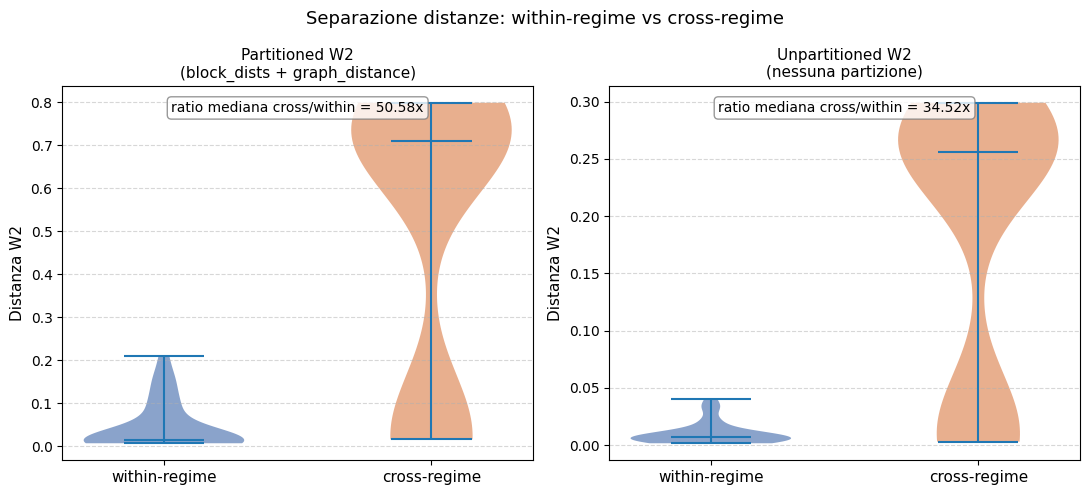

Separability (mediana cross / mediana within):
  Partitioned   : 0.7101 / 0.0140 = 50.58x
  Unpartitioned : 0.2563 / 0.0074 = 34.52x


In [41]:
# ── Raccolta delle distanze within/cross per entrambi i metodi ──────────────
within_part, cross_part = [], []
within_nopart, cross_nopart = [], []

for i, j in itertools.combinations(range(N), 2):
    ni, nj = keys[i][0], keys[j][0]   # nome del regime
    same_regime = (ni == nj)

    if same_regime:
        within_part.append(D[i, j])
        within_nopart.append(D_nopart[i, j])
    else:
        cross_part.append(D[i, j])
        cross_nopart.append(D_nopart[i, j])

within_part   = np.array(within_part)
cross_part    = np.array(cross_part)
within_nopart = np.array(within_nopart)
cross_nopart  = np.array(cross_nopart)

# ── Violin plot affiancato ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
fig.suptitle('Separazione distanze: within-regime vs cross-regime', fontsize=13)

for ax, (w, c, title) in zip(axes, [
    (within_part,   cross_part,   'Partitioned W2\n(block_dists + graph_distance)'),
    (within_nopart, cross_nopart, 'Unpartitioned W2\n(nessuna partizione)'),
]):
    data = [w, c]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True,
                          showextrema=True, widths=0.6)
    for pc in parts['bodies']:
        pc.set_alpha(0.65)
    parts['bodies'][0].set_facecolor('#4C72B0')
    parts['bodies'][1].set_facecolor('#DD8452')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['within-regime', 'cross-regime'], fontsize=11)
    ax.set_ylabel('Distanza W2', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotazione separability ratio
    ratio = np.median(c) / np.median(w)
    ax.text(0.5, 0.93, f'ratio mediana cross/within = {ratio:.2f}x',
            ha='center', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

print("Separability (mediana cross / mediana within):")
print(f"  Partitioned   : {np.median(cross_part):.4f} / {np.median(within_part):.4f}"
      f" = {np.median(cross_part)/np.median(within_part):.2f}x")
print(f"  Unpartitioned : {np.median(cross_nopart):.4f} / {np.median(within_nopart):.4f}"
      f" = {np.median(cross_nopart)/np.median(within_nopart):.2f}x")